# Model Improvement & Error Analysis

## Objective

The leakage-free XGBoost model achieved realistic performance after removing future-dependent features.

Instead of immediately applying more algorithms or balancing techniques, the objective of this notebook is to understand **where and why the model fails**.

Questions we aim to answer:

- Which orders are being misclassified?
- Which regions have the highest errors?
- Which purchase periods are difficult?
- Which payment methods lead to more mistakes?
- Which business patterns can be transformed into new features?

The findings from this notebook will guide the next iteration of feature engineering and model improvement.

In [4]:
#Cell 1 — Imports
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import confusion_matrix

In [5]:
#Cell 2 — Load Model
model = joblib.load(
    "../notebooks/models/late_delivery_xgboost_pipeline.joblib"
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [6]:
#Cell 3 — Load Dataset use exactly the same processed dataset.

DATA_PATH = Path("../data/processed/final_processed_datasets")

orders = pd.read_csv(
    DATA_PATH / "fact_orders_fe.csv"
)


In [7]:
#Cell 4 — Create Same Feature Set Exactly the same features as Notebook 9.

feature_columns = [

    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",

    "total_payment",
    "payment_count",
    "payment_type",

    "max_installments",

    "avg_payment_per_installment",

    "multiple_payment_methods",

    "purchase_year",
    "purchase_month",
    "purchase_month_name",

    "purchase_quarter",

    "purchase_day",

    "purchase_weekday",

    "purchase_hour",

    "estimated_delivery_days"

]

TARGET = "late_delivery_flag"

X = orders[feature_columns].copy()

y = orders[TARGET].astype(int)


In [8]:
#Cell 5 — Same Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)




In [9]:
#Cell 6 — Predictions
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [10]:
#Cell 7 — Error Analysis DataFrame


analysis_df = X_test.copy()

analysis_df["Actual"] = y_test.values

analysis_df["Predicted"] = y_pred

analysis_df["Probability"] = y_prob

In [11]:
analysis_df["Prediction_Type"] = np.select(

    [
        (analysis_df["Actual"] == 1) & (analysis_df["Predicted"] == 1),
        (analysis_df["Actual"] == 0) & (analysis_df["Predicted"] == 0),
        (analysis_df["Actual"] == 0) & (analysis_df["Predicted"] == 1),
        (analysis_df["Actual"] == 1) & (analysis_df["Predicted"] == 0),
    ],

    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
    ],

    default="Unknown"

)

analysis_df.head()

,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,avg_payment_per_installment,multiple_payment_methods,purchase_year,...,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,Actual,Predicted,Probability,Prediction_Type
10248,25900,mage,RJ,127.92,1.0,credit_card,6.0,21.32,False,2018,...,February,1,25,Sunday,19,24,1,0,0.125197,False Negative
91767,29164,serra,ES,89.36,1.0,credit_card,1.0,89.36,False,2018,...,April,2,13,Friday,16,27,0,0,0.058878,True Negative
53600,18520,cerquilho,SP,33.84,1.0,credit_card,3.0,11.28,False,2017,...,September,3,3,Sunday,17,24,0,0,0.003537,True Negative
97265,85301,laranjeiras do sul,PR,219.40,1.0,credit_card,1.0,219.40,False,2018,...,July,3,16,Monday,20,27,0,0,0.006838,True Negative
84430,36020,juiz de fora,MG,77.29,1.0,boleto,1.0,77.29,False,2018,...,March,1,11,Sunday,18,22,0,0,0.405398,True Negative


In [12]:
#Cell 9 — Count Errors
analysis_df["Prediction_Type"].value_counts()

Prediction_Type
True Negative     18091
False Negative     1366
False Positive      233
True Positive       199
Name: count, dtype: int64

In [13]:
#Cell 10 — False Negatives These are our biggest problem.

false_negatives = analysis_df[
    analysis_df["Prediction_Type"]=="False Negative"
]

false_negatives.head()

,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,avg_payment_per_installment,multiple_payment_methods,purchase_year,...,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,Actual,Predicted,Probability,Prediction_Type
10248,25900,mage,RJ,127.92,1.0,credit_card,6.0,21.320000,False,2018,...,February,1,25,Sunday,19,24,1,0,0.125197,False Negative
3540,22621,rio de janeiro,RJ,104.87,1.0,credit_card,3.0,34.956667,False,2018,...,January,1,12,Friday,4,33,1,0,0.021319,False Negative
60364,86706,arapongas,PR,63.99,1.0,debit_card,1.0,63.990000,False,2017,...,October,4,19,Thursday,13,20,1,0,0.046559,False Negative
48033,43870,jacuipe,BA,34.78,1.0,credit_card,3.0,11.593333,False,2017,...,April,2,28,Friday,9,33,1,0,0.002708,False Negative
4703,6542,santana de parnaiba,SP,803.04,1.0,credit_card,3.0,267.680000,False,2018,...,March,1,27,Tuesday,23,21,1,0,0.093644,False Negative


In [14]:
#Cell 11 — False Positives
false_positives = analysis_df[
    analysis_df["Prediction_Type"]=="False Positive"
]

false_positives.head()

,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,avg_payment_per_installment,multiple_payment_methods,purchase_year,...,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,Actual,Predicted,Probability,Prediction_Type
25402,22753,rio de janeiro,RJ,121.90,1.0,boleto,1.0,121.900000,False,2018,...,August,3,6,Monday,21,10,0,1,0.666107,False Positive
31041,23810,itaguai,RJ,33.22,1.0,credit_card,3.0,11.073333,False,2018,...,March,1,25,Sunday,15,18,0,1,0.557085,False Positive
27355,22713,rio de janeiro,RJ,132.08,1.0,debit_card,1.0,132.080000,False,2017,...,November,4,24,Friday,15,23,0,1,0.594825,False Positive
85623,48970,senhor do bonfim,BA,277.48,1.0,credit_card,10.0,27.748000,False,2018,...,April,2,1,Sunday,22,28,0,1,0.578510,False Positive
2036,79112,campo grande,MS,52.36,1.0,credit_card,4.0,13.090000,False,2018,...,August,3,10,Friday,12,11,0,1,0.745706,False Positive


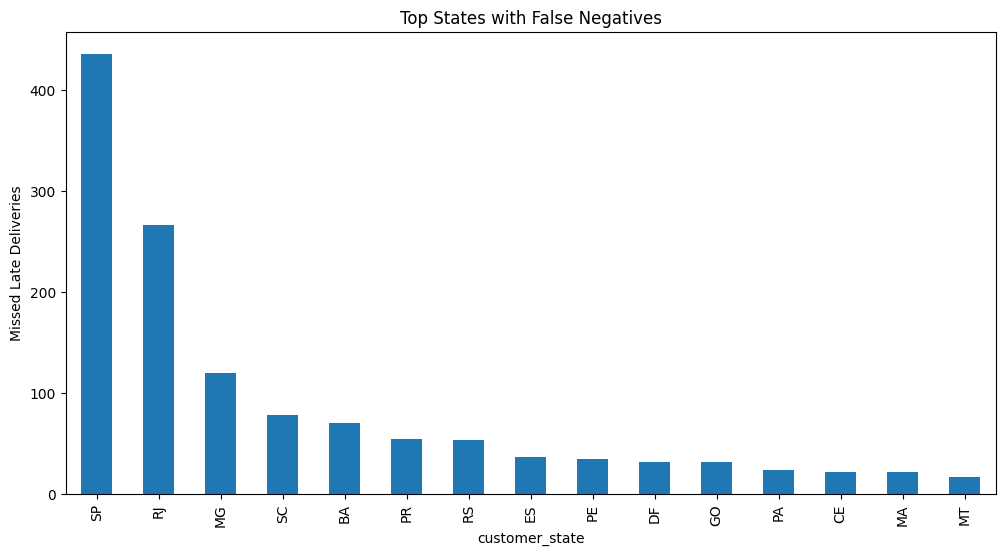

In [15]:
#Cell 12 — False Negatives by State
plt.figure(figsize=(12,6))

false_negatives["customer_state"]\
.value_counts()\
.head(15)\
.plot(kind="bar")

plt.title("Top States with False Negatives")

plt.ylabel("Missed Late Deliveries")

plt.show()

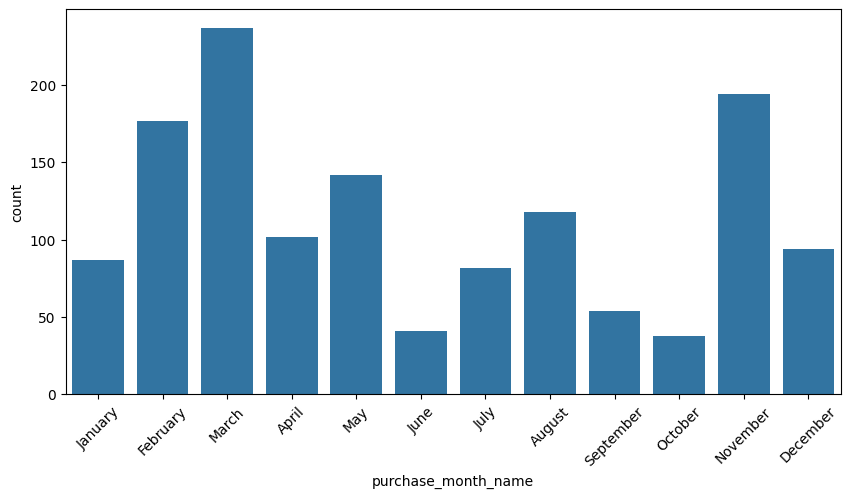

In [16]:
#Cell 13 — False Negatives by Month
plt.figure(figsize=(10,5))

sns.countplot(
    data=false_negatives,
    x="purchase_month_name",
    order=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]
)

plt.xticks(rotation=45)
plt.show()

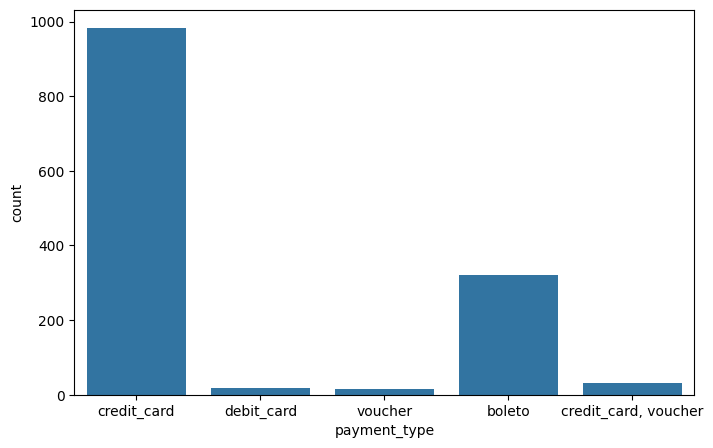

In [17]:
#Cell 14 — False Negatives by Payment Type
plt.figure(figsize=(8,5))

sns.countplot(
    data=false_negatives,
    x="payment_type"
)
plt.show()

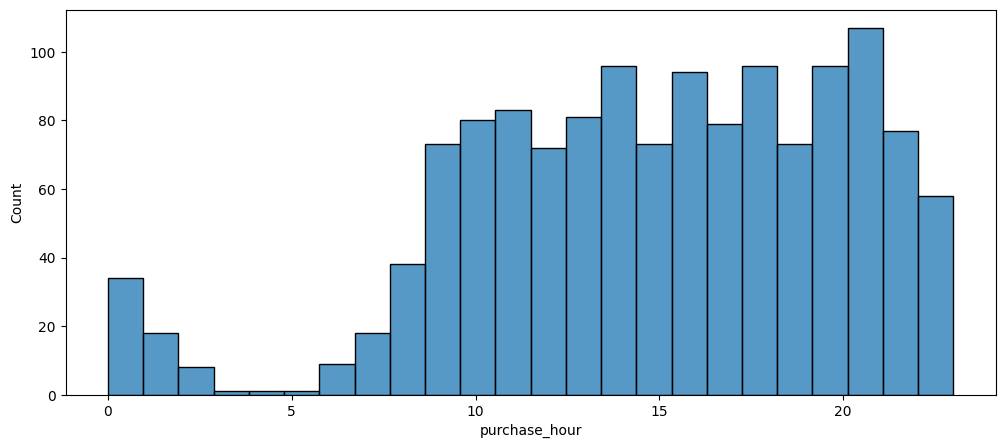

In [18]:
#Cell 15 — False Negatives by Purchase Hour
plt.figure(figsize=(12,5))

sns.histplot(

    false_negatives["purchase_hour"],

    bins=24

)

plt.show()

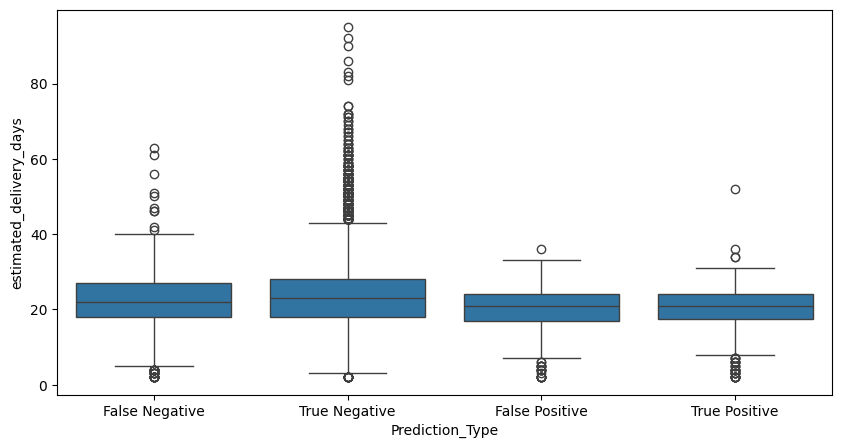

In [19]:
# Cell 16 — Estimated Delivery Days
plt.figure(figsize=(10,5))

sns.boxplot(

    data=analysis_df,

    x="Prediction_Type",

    y="estimated_delivery_days"

)

plt.show()

In [20]:
# Total late deliveries by state
late_orders = analysis_df[analysis_df["Actual"] == 1]

late_state = (
    late_orders
    .groupby("customer_state")
    .size()
    .rename("Late Orders")
)

fn_state = (
    false_negatives
    .groupby("customer_state")
    .size()
    .rename("False Negatives")
)

state_analysis = (
    pd.concat([late_state, fn_state], axis=1)
    .fillna(0)
)

state_analysis["FN Rate"] = (
    state_analysis["False Negatives"]
    / state_analysis["Late Orders"]
)

state_analysis = state_analysis.sort_values(
    "FN Rate",
    ascending=False
)

state_analysis.head(15)

,Late Orders,False Negatives,FN Rate
customer_state,,,
AC,1,1,1.000000
AM,1,1,1.000000
PR,54,54,1.000000
PB,10,10,1.000000
RO,2,2,1.000000
RN,11,11,1.000000
MT,17,17,1.000000
PE,37,35,0.945946
DF,34,32,0.941176


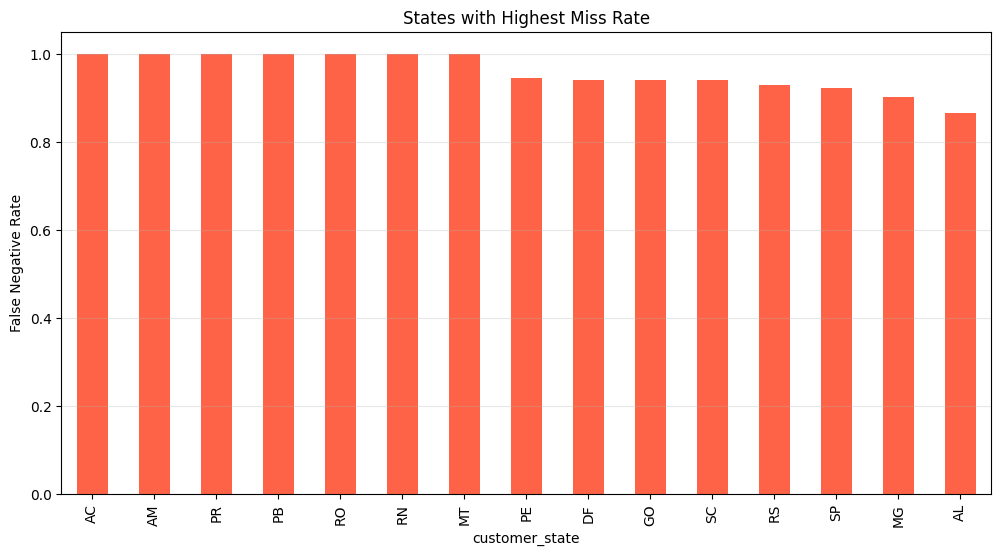

In [21]:
#Step 18 — Visualize FN Rate
plt.figure(figsize=(12,6))

state_analysis.head(15)["FN Rate"].plot(
    kind="bar",
    color="tomato"
)

plt.ylabel("False Negative Rate")
plt.title("States with Highest Miss Rate")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [22]:
#step 19 FALSE NEGATIVE BY MONTH
late_month = (
    late_orders
    .groupby("purchase_month_name")
    .size()
)

fn_month = (
    false_negatives
    .groupby("purchase_month_name")
    .size()
)

month_analysis = (
    pd.concat(
        [late_month, fn_month],
        axis=1
    )
)

month_analysis.columns = [
    "Late Orders",
    "False Negatives"
]

month_analysis = month_analysis.fillna(0)

month_analysis["FN Rate"] = (
    month_analysis["False Negatives"]
    / month_analysis["Late Orders"]
)

month_analysis.sort_values(
    "FN Rate",
    ascending=False
)

,Late Orders,False Negatives,FN Rate
purchase_month_name,,,
June,41,41,1.000000
January,88,87,0.988636
April,104,102,0.980769
July,84,82,0.976190
October,39,38,0.974359
September,56,54,0.964286
May,149,142,0.953020
December,103,94,0.912621
November,219,194,0.885845


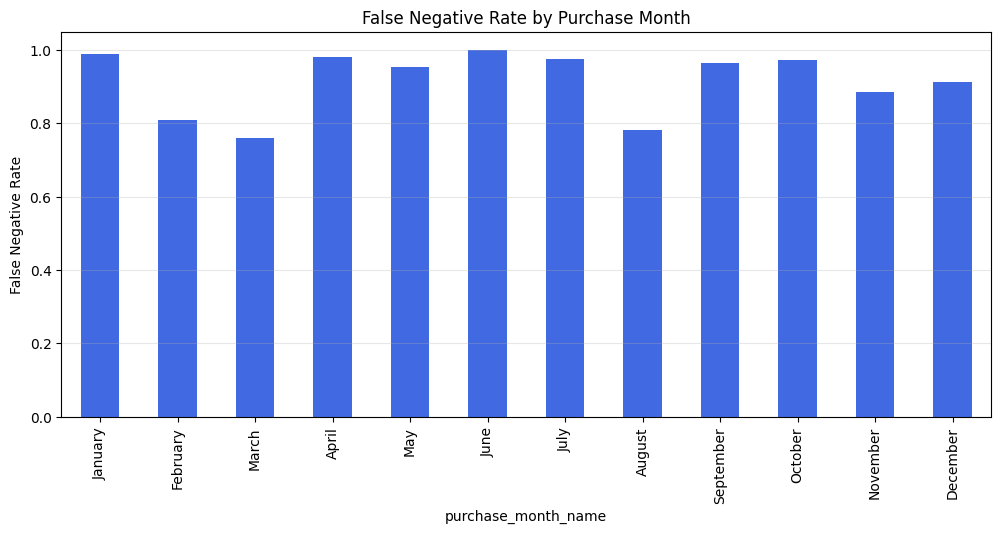

In [23]:
#Step 20: MONTHLY VISUALIZATION
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

month_analysis = month_analysis.reindex(month_order)

plt.figure(figsize=(12,5))

month_analysis["FN Rate"].plot(
    kind="bar",
    color="royalblue"
)

plt.ylabel("False Negative Rate")
plt.title("False Negative Rate by Purchase Month")

plt.grid(axis="y", alpha=0.3)

plt.show()

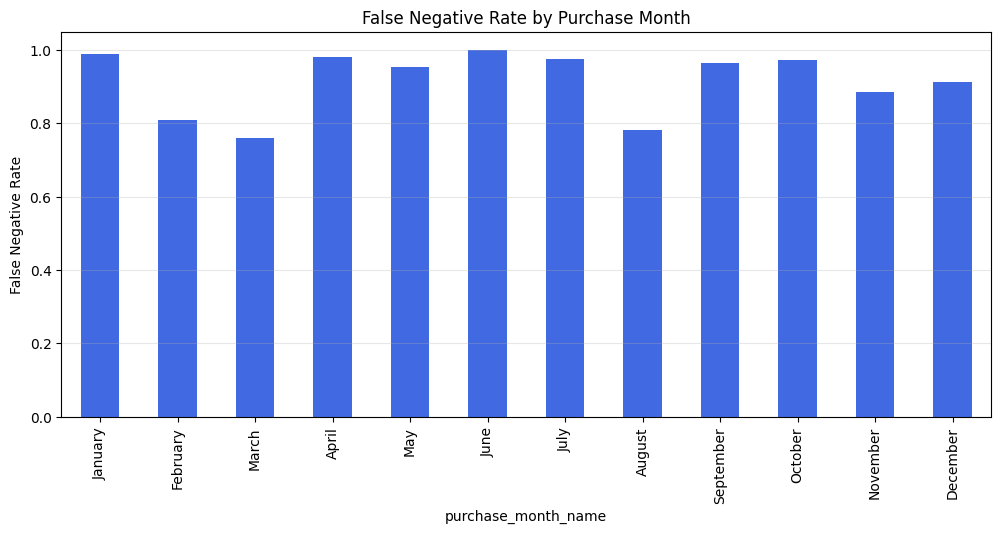

In [24]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

month_analysis = month_analysis.reindex(month_order)

plt.figure(figsize=(12,5))

month_analysis["FN Rate"].plot(
    kind="bar",
    color="royalblue"
)

plt.ylabel("False Negative Rate")
plt.title("False Negative Rate by Purchase Month")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [25]:
from scipy.stats import mannwhitneyu

fn = false_negatives["estimated_delivery_days"]

tp = analysis_df[
    analysis_df["Prediction_Type"]=="True Positive"
]["estimated_delivery_days"]

stat,p = mannwhitneyu(fn,tp)

print("Statistic :",stat)

print("P-value   :",p)

Statistic : 158913.0
P-value   : 0.0001110882521238379


In [26]:
numeric_columns = [

    "total_payment",

    "avg_payment_per_installment",

    "estimated_delivery_days",

    "purchase_hour",

    "purchase_day",

    "purchase_month",

    "customer_zip_code_prefix"

]

results=[]

true_positive = analysis_df[
    analysis_df["Prediction_Type"]=="True Positive"
]

for col in numeric_columns:

    stat,p=mannwhitneyu(

        false_negatives[col],

        true_positive[col]

    )

    results.append({

        "Feature":col,

        "P-value":p

    })

pd.DataFrame(results).sort_values("P-value")

,Feature,P-value
2,estimated_delivery_days,0.000111
5,purchase_month,0.003197
4,purchase_day,0.070828
1,avg_payment_per_installment,0.089804
0,total_payment,0.099837
3,purchase_hour,0.326611
6,customer_zip_code_prefix,0.923558


In [27]:
from scipy.stats import chi2_contingency

categorical_columns=[

    "customer_state",

    "payment_type",

    "purchase_month_name",

    "purchase_weekday"

]

chi_results=[]

comparison=analysis_df[
    analysis_df["Prediction_Type"].isin(

        [

            "False Negative",

            "True Positive"

        ]

    )

]

for col in categorical_columns:

    table=pd.crosstab(

        comparison[col],

        comparison["Prediction_Type"]

    )

    chi2,p,_,_=chi2_contingency(table)

    chi_results.append({

        "Feature":col,

        "P-value":p

    })

pd.DataFrame(chi_results).sort_values("P-value")


,Feature,P-value
2,purchase_month_name,2.287281e-18
0,customer_state,5.655050e-12
3,purchase_weekday,4.024369e-01
1,payment_type,9.956855e-01


In [28]:
MIN_LATE_ORDERS = 50

reliable_states = state_analysis[
    state_analysis["Late Orders"] >= MIN_LATE_ORDERS
].sort_values("FN Rate", ascending=False)

reliable_states

,Late Orders,False Negatives,FN Rate
customer_state,,,
PR,54,54,1.000000
SC,83,78,0.939759
RS,57,53,0.929825
SP,472,436,0.923729
MG,133,120,0.902256
BA,83,70,0.843373
RJ,346,267,0.771676


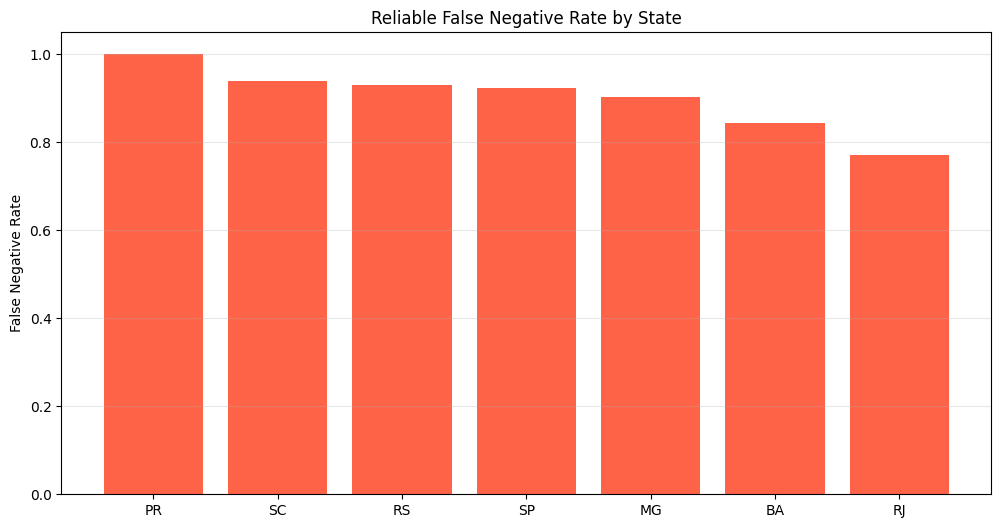

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    reliable_states.index,
    reliable_states["FN Rate"],
    color="tomato"
)

plt.ylabel("False Negative Rate")
plt.title("Reliable False Negative Rate by State")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [30]:
analysis_df["delivery_bucket"] = pd.cut(

    analysis_df["estimated_delivery_days"],

    bins=[0,7,14,21,28,35,100],

    labels=[
        "0-7",
        "8-14",
        "15-21",
        "22-28",
        "29-35",
        "35+"
    ]

)

In [35]:
delivery_analysis = pd.concat(
    [
        late_delivery_bucket,
        fn_delivery_bucket
    ],
    axis=1
)

delivery_analysis.columns = [
    "Late Orders",
    "False Negatives"
]

delivery_analysis = delivery_analysis.fillna(0)

delivery_analysis["FN Rate"] = (
    delivery_analysis["False Negatives"]
    /
    delivery_analysis["Late Orders"]
)

delivery_analysis

,Late Orders,False Negatives,FN Rate
delivery_bucket,,,
0-7,107,75,0.700935
8-14,143,138,0.965035
15-21,505,428,0.847525
22-28,561,486,0.866310
29-35,200,192,0.960000
35+,49,47,0.959184


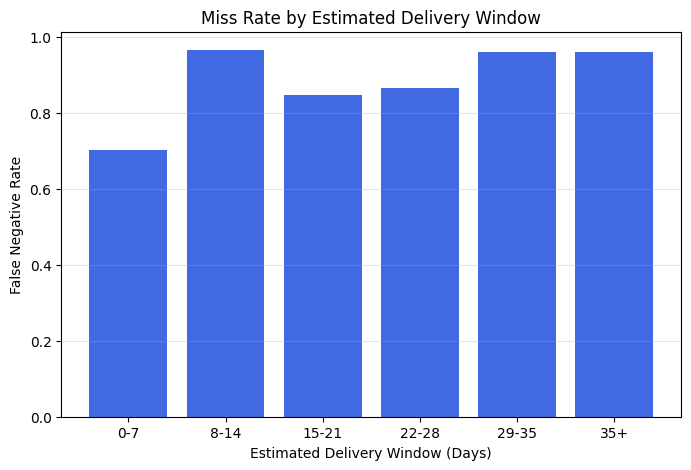

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    delivery_analysis.index.astype(str),
    delivery_analysis["FN Rate"],
    color="royalblue"
)

plt.ylabel("False Negative Rate")
plt.xlabel("Estimated Delivery Window (Days)")
plt.title("Miss Rate by Estimated Delivery Window")

plt.grid(axis="y", alpha=0.3)

plt.show()

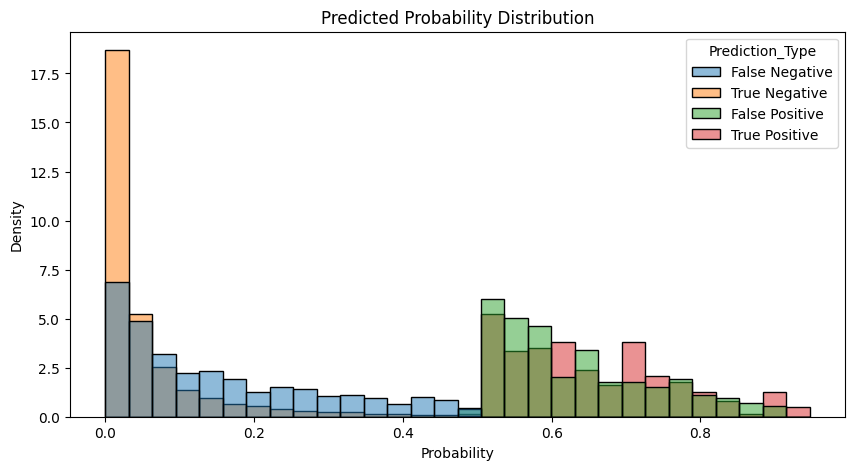

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(

    data=analysis_df,

    x="Probability",

    hue="Prediction_Type",

    bins=30,

    stat="density",

    common_norm=False

)

plt.title("Predicted Probability Distribution")

plt.show()

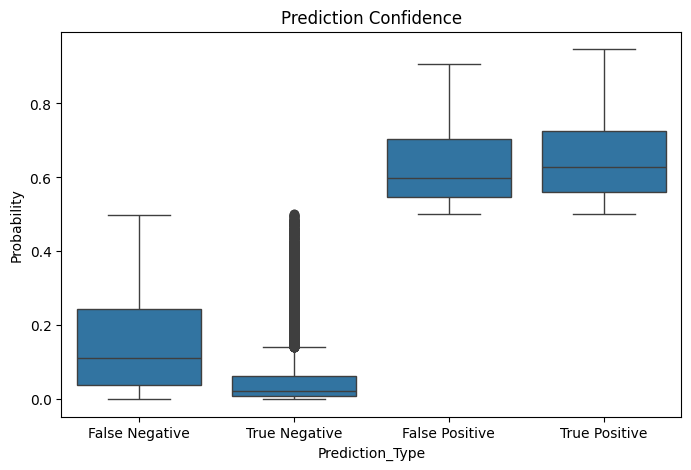

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=analysis_df,

    x="Prediction_Type",

    y="Probability"

)

plt.title("Prediction Confidence")

plt.show()

In [39]:
hard_cases = false_negatives.sort_values(

    "Probability",

    ascending=False

)

hard_cases.head(20)

,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,avg_payment_per_installment,multiple_payment_methods,purchase_year,...,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,Actual,Predicted,Probability,Prediction_Type
22360,22790,rio de janeiro,RJ,146.25,1.0,credit_card,6.0,24.375000,False,2018,...,February,1,9,Friday,15,25,1,0,0.499046,False Negative
93271,23076,rio de janeiro,RJ,35.40,1.0,credit_card,1.0,35.400000,False,2018,...,February,1,28,Wednesday,14,19,1,0,0.497185,False Negative
82364,91770,porto alegre,RS,62.70,1.0,credit_card,3.0,20.900000,False,2018,...,February,1,21,Wednesday,21,27,1,0,0.494526,False Negative
34385,28013,campos dos goytacazes,RJ,48.13,1.0,boleto,1.0,48.130000,False,2018,...,March,1,12,Monday,0,20,1,0,0.494355,False Negative
66963,28685,japuiba,RJ,54.78,1.0,credit_card,1.0,54.780000,False,2017,...,November,4,22,Wednesday,13,22,1,0,0.493672,False Negative
88170,2728,sao paulo,SP,180.33,1.0,boleto,1.0,180.330000,False,2018,...,August,3,14,Tuesday,8,2,1,0,0.492195,False Negative
14980,40710,salvador,BA,163.90,1.0,credit_card,5.0,32.780000,False,2017,...,November,4,27,Monday,16,23,1,0,0.492001,False Negative
9923,26021,nova iguacu,RJ,304.77,1.0,credit_card,5.0,60.954000,False,2017,...,November,4,28,Tuesday,19,21,1,0,0.488238,False Negative
1567,23095,rio de janeiro,RJ,504.35,1.0,credit_card,4.0,126.087500,False,2018,...,February,1,28,Wednesday,22,19,1,0,0.487718,False Negative
10920,28942,sao pedro da aldeia,RJ,57.21,1.0,credit_card,5.0,11.442000,False,2017,...,November,4,22,Wednesday,18,20,1,0,0.486250,False Negative


In [42]:
easy_misses = false_negatives.sort_values(

    "Probability"

)

easy_misses.head(10)

,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,avg_payment_per_installment,multiple_payment_methods,purchase_year,...,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,Actual,Predicted,Probability,Prediction_Type
32383,98280,panambi,RS,91.12,1.0,credit_card,4.0,22.780000,False,2017,...,April,2,29,Saturday,20,36,1,0,0.000470,False Negative
18731,29278,arace,ES,44.63,1.0,credit_card,2.0,22.315000,False,2018,...,June,2,2,Saturday,18,40,1,0,0.000804,False Negative
51579,2022,sao paulo,SP,139.16,1.0,credit_card,3.0,46.386667,False,2018,...,June,2,5,Tuesday,9,23,1,0,0.001179,False Negative
30488,52165,recife,PE,123.21,1.0,debit_card,1.0,123.210000,False,2017,...,December,4,20,Wednesday,22,63,1,0,0.001270,False Negative
70110,20540,rio de janeiro,RJ,207.57,1.0,voucher,1.0,207.570000,False,2017,...,May,2,29,Monday,10,22,1,0,0.001373,False Negative
60069,3518,sao paulo,SP,106.23,1.0,credit_card,10.0,10.623000,False,2017,...,December,4,19,Tuesday,23,20,1,0,0.001408,False Negative
96140,6160,osasco,SP,17.29,1.0,credit_card,1.0,17.290000,False,2018,...,April,2,23,Monday,16,14,1,0,0.001608,False Negative
82993,3983,sao paulo,SP,47.38,1.0,credit_card,4.0,11.845000,False,2018,...,April,2,1,Sunday,20,10,1,0,0.001660,False Negative
92957,5336,sao paulo,SP,60.86,1.0,boleto,1.0,60.860000,False,2017,...,February,1,4,Saturday,10,36,1,0,0.001763,False Negative
4053,3315,sao paulo,SP,175.77,1.0,credit_card,1.0,175.770000,False,2017,...,May,2,31,Wednesday,13,22,1,0,0.001938,False Negative


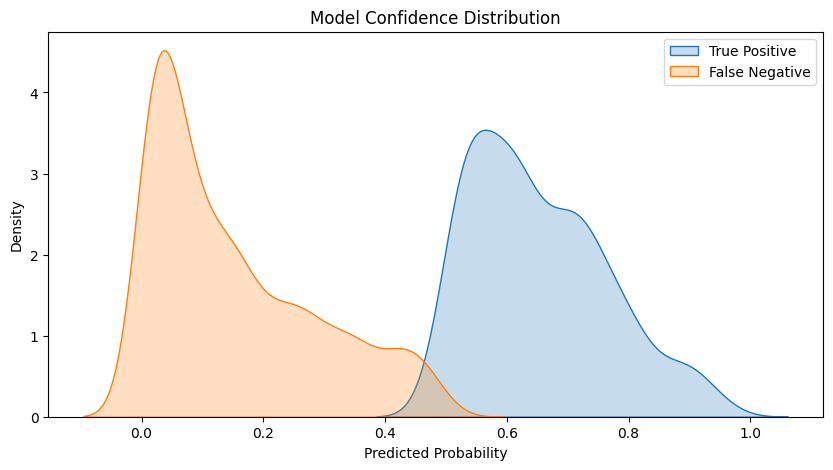

In [41]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    analysis_df.loc[
        analysis_df["Prediction_Type"]=="True Positive",
        "Probability"
    ],
    label="True Positive",
    fill=True
)

sns.kdeplot(
    analysis_df.loc[
        analysis_df["Prediction_Type"]=="False Negative",
        "Probability"
    ],
    label="False Negative",
    fill=True
)

plt.title("Model Confidence Distribution")

plt.xlabel("Predicted Probability")

plt.legend()

plt.show()